## ADVANCED PREPROCESSING

Import libraries

In [54]:
import pandas as pd
import re
import nltk
import emoji

# from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns


LOAD DATASET

In [55]:
df = pd.read_csv(r"C:\Users\91904\Desktop\ksfe\AI\CODE\review_rating_system\data\cleaned_reviews.csv")

In [56]:
df

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...
...,...,...
393670,5,Great for sesame chicken..this is a good if no...
393671,2,I'm disappointed with the flavor. The chocolat...
393672,5,"These stars are small, so you can give 10-15 o..."
393673,5,These are the BEST treats for training and rew...


data set contain 393675 rows and 2 columns

DOWNLOAD NLTK RESOURCES

In [57]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91904\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91904\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\91904\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 1. Convert Text to Lowercase

Convert all review text to lowercase to maintain consistency.

In [58]:
# Convert the review text to lowercase
df["Text"] = df["Text"].str.lower()

# Display the first 5 rows
df.head()

,Score,Text
0,5,i have bought several of the vitality canned d...
1,1,product arrived labeled as jumbo salted peanut...
2,4,this is a confection that has been around a fe...
3,2,if you are looking for the secret ingredient i...
4,5,great taffy at a great price. there was a wid...


## 2. Check and Remove HTML Tags

HTML tags can appear in review text, such as `<br>`, `<p>`, `<div>`, etc.

In [59]:

# Check for HTML tags
html_pattern = r"<[^>]+>"

html_count = df["Text"].str.contains(
    html_pattern,
    regex=True,
    na=False
).sum()

print("Number of reviews containing HTML tags:", html_count)

Number of reviews containing HTML tags: 102931


Number of reviews containing HTML tags: 102931

In [60]:
# Remove HTML tags
df["Text"] = df["Text"].str.replace(
    html_pattern,
    "",
    regex=True
)

### 3. **Remove URLs**

- Checks for URLs in the review text.
- Finds and prints the number of reviews containing URLs.
- Removes URLs from the review text.
- Verifies that no URLs remain.

In [61]:
# URL pattern
url_pattern = r'https?://\S+|www\.\S+'

# 1. Check and find count
url_count = df["Text"].str.contains(
    url_pattern,
    regex=True,
    na=False
).sum()

print("Number of reviews containing URLs:", url_count)

# 2. Remove URLs
df["Text"] = df["Text"].str.replace(
    url_pattern,
    "",
    regex=True
)

# 3. Verify
remaining_urls = df["Text"].str.contains(
    url_pattern,
    regex=True,
    na=False
).sum()

print("URLs remaining after removal:", remaining_urls)

Number of reviews containing URLs: 361
URLs remaining after removal: 0


Number of reviews containing URLs: 361

### 4. **Remove Emojis**

- Checks for emojis in the review text.
- Finds and prints the number of reviews containing emojis.
- Removes emojis from the review text.
- Verifies that no emojis remain.

In [62]:


# Make sure Text column contains normal Python strings
df["Text"] = df["Text"].astype("object")

# Emoji pattern
emoji_pattern = re.compile(r'[\U00010000-\U0010ffff]')

# 1. Check and find count
emoji_count = df["Text"].apply(
    lambda x: bool(emoji_pattern.search(str(x)))
).sum()

print("Number of reviews containing emojis:", emoji_count)



Number of reviews containing emojis: 0


Number of reviews containing emojis: 0

### 5. **Remove Punctuation and Special Characters**

- Checks for punctuation and special characters.
- Finds and prints the number of reviews containing them.
- Keeps only alphabetic characters and spaces.
- Removes punctuation and special characters.
- Verifies the cleaned text.

In [63]:

# 1. Check and find count
special_pattern = r'[^a-zA-Z\s]'

special_count = df["Text"].str.contains(
    special_pattern,
    regex=True,
    na=False
).sum()

print("Number of reviews containing punctuation/special characters:", special_count)

# 2. Remove punctuation and special characters
df["Text"] = df["Text"].str.replace(
    special_pattern,
    "",
    regex=True
)

# 3. Verify
remaining_special = df["Text"].str.contains(
    special_pattern,
    regex=True,
    na=False
).sum()

print("Punctuation/special characters remaining:", remaining_special)

Number of reviews containing punctuation/special characters: 392842
Punctuation/special characters remaining: 0


Number of reviews containing punctuation/special characters: 392842

6. Remove Extra Spaces
Checks for reviews containing extra spaces.
Finds and prints the number of reviews containing extra spaces.
Removes leading, trailing, and repeated spaces.
Verifies the cleaned text.

In [64]:
# 1. Check and find count
extra_space_count = df["Text"].str.contains(
    r"\s{2,}|^\s|\s$",
    regex=True,
    na=False
).sum()

print("Number of reviews containing extra spaces:", extra_space_count)

# 2. Remove extra spaces
df["Text"] = df["Text"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

# 3. Verify
remaining_extra_spaces = df["Text"].str.contains(
    r"\s{2,}|^\s|\s$",
    regex=True,
    na=False
).sum()

print("Extra spaces remaining:", remaining_extra_spaces)

Number of reviews containing extra spaces: 271394
Extra spaces remaining: 0


Number of reviews containing extra spaces: 271394

7. Lemmatization
Checks the text before lemmatization.
Applies lemmatization to convert words to their base form.
Verifies the cleaned text.

In [65]:
lemmatizer = WordNetLemmatizer()
# Load english stop words
stop_words = set(stopwords.words('english'))

# 1. Check before processing
print("Before processing:")
print(df["Text"].head())

# 2. Lemmatization & Stop Word Removal
def clean_and_lemmatize(text):
    if not isinstance(text, str):
        return ""
    # Split, remove stop words, and lemmatize
    words = text.split()
    words = [
        lemmatizer.lemmatize(word) 
        for word in words 
        if word.lower() not in stop_words
    ]
    return " ".join(words)

df["Text"] = df["Text"].apply(clean_and_lemmatize)

# 3. Verify
print("\nAfter processing (Lemmatized + Stop Words Removed):")
print(df["Text"].head())

Before processing:
0    i have bought several of the vitality canned d...
1    product arrived labeled as jumbo salted peanut...
2    this is a confection that has been around a fe...
3    if you are looking for the secret ingredient i...
4    great taffy at a great price there was a wide ...
Name: Text, dtype: object

After processing (Lemmatized + Stop Words Removed):
0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanutsth...
2    confection around century light pillowy citrus...
3    looking secret ingredient robitussin believe f...
4    great taffy great price wide assortment yummy ...
Name: Text, dtype: str


8. Remove Reviews with Fewer Than 3 Words
Checks the number of words in each review.
Finds and prints the number of reviews with fewer than 3 words.
Removes those reviews.
Verifies that no review with fewer than 3 words remains.

In [66]:
# 1. Count words in each review
word_count = df["Text"].str.split().str.len()

# 2. Check and find count
short_reviews = word_count < 3

print("Number of reviews with fewer than 3 words:",
      short_reviews.sum())

# 3. Remove reviews with fewer than 3 words
df = df[~short_reviews].copy()

# 4. Verify
word_count_after = df["Text"].str.split().str.len()

print("Reviews remaining:", len(df))
print("Minimum number of words:", word_count_after.min())

Number of reviews with fewer than 3 words: 15
Reviews remaining: 393660
Minimum number of words: 3


Number of reviews with fewer than 3 words: 11
Reviews remaining: 393664
Minimum number of words: 3

9. Remove Excessively Long Reviews

For your review-rating dataset, let's use 500 words as the maximum length.

Checks the number of words in each review.
Finds and prints the number of reviews with more than 500 words.
Removes excessively long reviews.
Verifies the maximum word count after removal.

In [67]:
# Maximum allowed number of words
MAX_WORDS = 500

# 1. Count words in each review
word_count = df["Text"].str.split().str.len()

# 2. Check and find count
long_reviews = word_count > MAX_WORDS

print("Number of reviews with more than",
      MAX_WORDS, "words:", long_reviews.sum())

# 3. Remove excessively long reviews
df = df[~long_reviews].copy()

# 4. Verify
word_count_after = df["Text"].str.split().str.len()

print("Reviews remaining:", len(df))
print("Maximum number of words:", word_count_after.max())

Number of reviews with more than 500 words: 148
Reviews remaining: 393512
Maximum number of words: 499


Number of reviews with more than 500 words: 1301
Reviews remaining: 392363
Maximum number of words: 500

##  Save new csv in the data folder

In [68]:
df.to_csv(
    r"C:\Users\91904\Desktop\ksfe\AI\CODE\review_rating_system\data\model_learning_data.csv",
    index=False
)

## Data Visualization

The following plots show review counts, word-count distributions, and sample reviews for each rating.

In [69]:
# !pip install --upgrade seaborn

In [70]:


sns.set_theme(style="whitegrid")

# Calculate word count for each review
df["word_count"] = df["Text"].str.split().str.len()

# Sort ratings numerically
rating_order = sorted(df["Score"].dropna().unique())

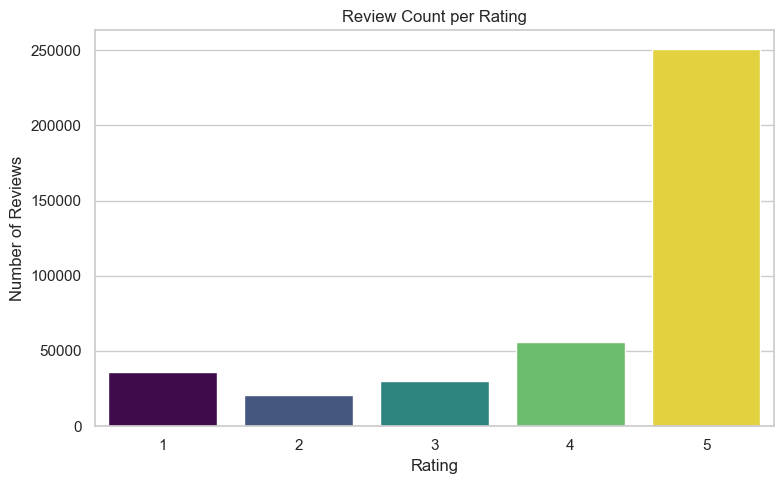

In [71]:
# 1. Bar plot: Review count per rating

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Score",
    order=rating_order,
    hue="Score",
    palette="viridis",
    legend=False
)

plt.title("Review Count per Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

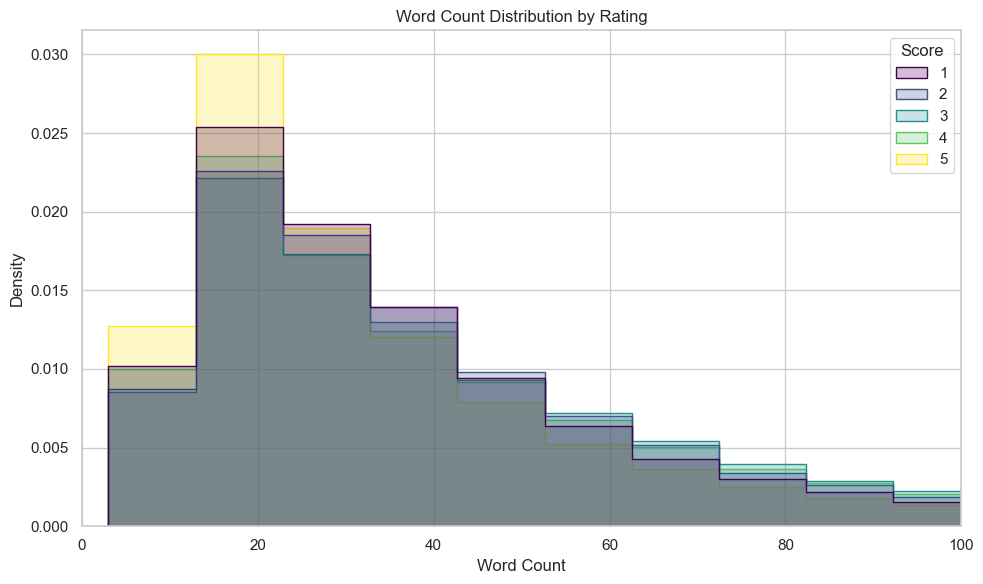

In [72]:
# 2. Histogram: Word-count distribution by rating

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    hue="Score",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    palette="viridis"
)

plt.title("Word Count Distribution by Rating")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

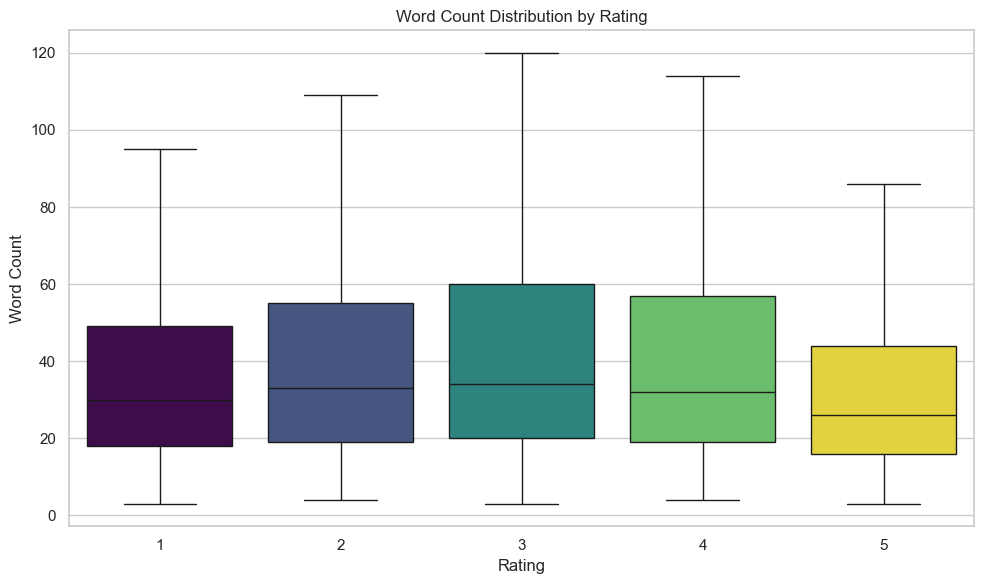

In [73]:
# 2. Box plot: Word-count distribution by rating

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Score",
    y="word_count",
    order=rating_order,
    hue="Score",
    palette="viridis",
    legend=False,
    showfliers=False
)

plt.title("Word Count Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

In [74]:
# 3. Display full sample reviews per rating

SAMPLE_REVIEWS = 5  # Set any value from 3 to 10

for rating in rating_order:
    rating_reviews = df.loc[
        df["Score"] == rating, "Text"
    ].dropna()

    sample_reviews = rating_reviews.sample(
        n=min(SAMPLE_REVIEWS, len(rating_reviews)),
        random_state=42
    )

    print(f"\n{'=' * 90}")
    print(f"RATING: {rating}")
    print(f"{'=' * 90}")

    for number, review in enumerate(sample_reviews, start=1):
        print(f"\nReview {number}:\n{review}")


RATING: 1

Review 1:
like another reviewer received box nearly expired product consume within month ordering good deal otherwise buy elsewhere

Review 2:
bad looking forward awful unusable smelled exactly like anatomy class dissection room unmistakable odor guess chemical added preserve anyway disappointment returned thanks making easy least amazon

Review 3:
saw local grocer love deep dish pizza buy onei followed direction tee sadlythe heavy hulking pizza turned major turdthe crust way hard around edge inside crustwell ever eaten dough felt like started expand stomache sausage tasted like mouse droppings sauce ok nothing remarkablethe good thing cheese reallyhow hard mess cheeseall dont recommend pizza doesnt cook right even following direction word wordif want good frozen deep dish nothing beat davannisfor youre paying expect product thatsyou knowedibleyou wont get hereunless like rock hard crust mouse poop sausagenot recommended

Review 4:
know serious would give option love amazon